In [1]:
import numpy as np
from skimage.registration import phase_cross_correlation
import os
from matplotlib import pyplot as plt
import cv2
from skimage.transform import warp

In [2]:
file_name = "merged_shifted_final"
folder_name = "../results/grayscale_example/"
result_dir = "../results/grayscale_example/image_registration/"
os.makedirs(result_dir, exist_ok=True)

In [3]:
sparse_matrix_x = np.load(folder_name+file_name+'_x.npy').T
sparse_matrix_y = np.load(folder_name+file_name+'_y.npy')
print(sparse_matrix_x.shape, sparse_matrix_y.shape)
plt.imsave(os.path.join(result_dir, "test_shift_x_original.png"), sparse_matrix_x[::8, ::8], vmin=-1, vmax=1)
plt.imsave(os.path.join(result_dir, "test_shift_y_original.png"), sparse_matrix_y[::8, ::8], vmin=-1, vmax=1)

(6330, 7190) (7190, 6320)


In [4]:
values = sparse_matrix_x[sparse_matrix_x != 0]

bins = np.arange(-40.5, 41.5, 1)   # edges at -40.5, -39.5, ..., 40.5

fig, ax = plt.subplots()
ax.hist(values, bins=bins, color="steelblue", edgecolor="black")
ax.set_yscale("log")
ax.set_xlabel("value")
ax.set_ylabel("count (log scale)")
ax.set_title("Distribution of non-zero values")
fig.savefig(os.path.join(result_dir, "value_distribution.svg"))
plt.close(fig)

print(f"non-zero count: {values.size}")
print(f"min / max:      {values.min():.3f} / {values.max():.3f}")
print(f"mean / median:  {values.mean():.3f} / {np.median(values):.3f}")
print(f"std:            {values.std():.3f}")
p50  = np.percentile(values, 50)   # median
p95  = np.percentile(values, 98)   # 80th percentile

print(f"median (50%): {p50:.3f}")
print(f"95th pct:     {p95:.3f}")


non-zero count: 26140408
min / max:      -34.000 / 31.000
mean / median:  0.051 / 1.000
std:            3.910
median (50%): 1.000
95th pct:     9.000


In [5]:
sparse_matrix_x = np.clip(sparse_matrix_x, -35, 35)
sparse_matrix_y = np.clip(sparse_matrix_y, -35, 35)

(4000, 4000) (4000, 4000)


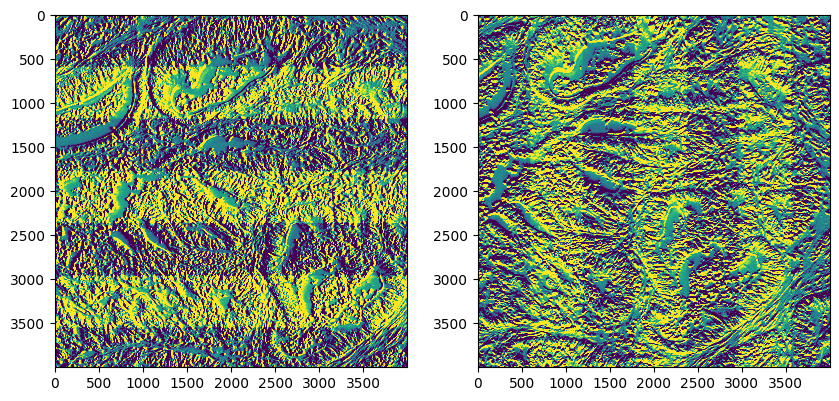

In [6]:
center_x, center_y = 3000, 3000
half_size = 2000
crop_box = (center_x-half_size, center_y-half_size, center_x+half_size, center_y+half_size)
sparse_matrix_x_crop = sparse_matrix_x[crop_box[0]:crop_box[2], crop_box[1]:crop_box[3]]
sparse_matrix_y_crop = sparse_matrix_y[crop_box[0]:crop_box[2], crop_box[1]:crop_box[3]]
print(sparse_matrix_x_crop.shape, sparse_matrix_y_crop.shape)
# plot the cropped matrices
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop, vmax=1, vmin=-1)
ax1.imshow(sparse_matrix_y_crop, vmax=1, vmin=-1)
plt.show()

[  0  30  34  40  44  50  54  60  64  70  80  90 100 110 120 130 140 150
 160 170 180 190 200 210 220 230 240 250] [11524331  1386930       22   904416        8   619821        4   435924
        2   314424   227244   165675   120540    87545    62706    45250
    32672    23419    16109    11230     7728     5166     3522     2225
     1370      914      524      279]
[  0  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180 190
 200 210 220] [12440975  1215860   773075   515521   349793   240314   164618   111454
    74467    48630    29988    17517     9431     4877     2166      874
      325       86       13        9        7]


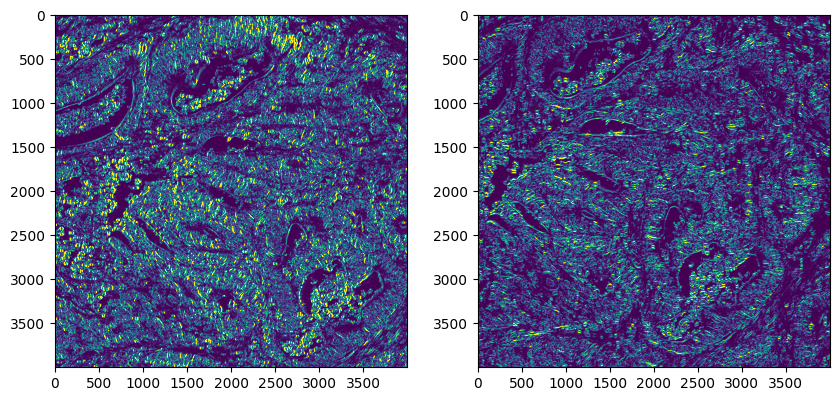

In [7]:
sparse_matrix_x_crop_abs = (np.abs(sparse_matrix_x_crop).astype(np.uint8)) * 10
sparse_matrix_y_crop_abs = (np.abs(sparse_matrix_y_crop).astype(np.uint8)) * 10
sparse_matrix_x_crop_abs = np.where(sparse_matrix_x_crop_abs < 30, 0, sparse_matrix_x_crop_abs)
sparse_matrix_y_crop_abs = np.where(sparse_matrix_y_crop_abs < 30, 0, sparse_matrix_y_crop_abs)
unique, counts = np.unique(sparse_matrix_x_crop_abs, return_counts=True)
print(unique, counts)
unique, counts = np.unique(sparse_matrix_y_crop_abs, return_counts=True)
print(unique, counts)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop_abs, vmin=0, vmax=62)
ax1.imshow(sparse_matrix_y_crop_abs, vmin=0, vmax=62)
plt.show()

[181. 522.]


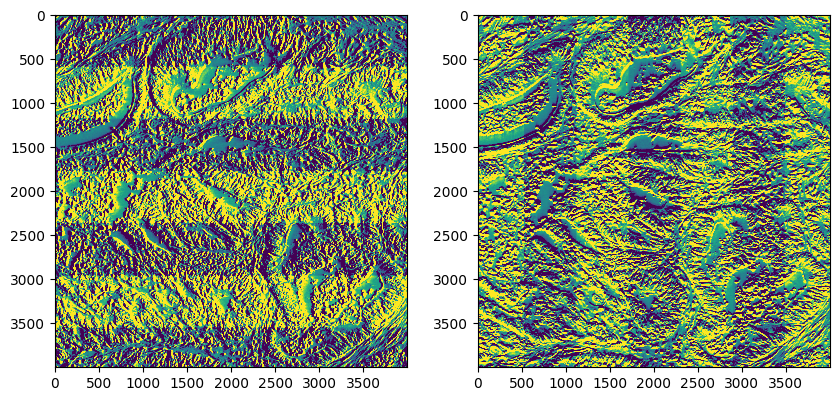

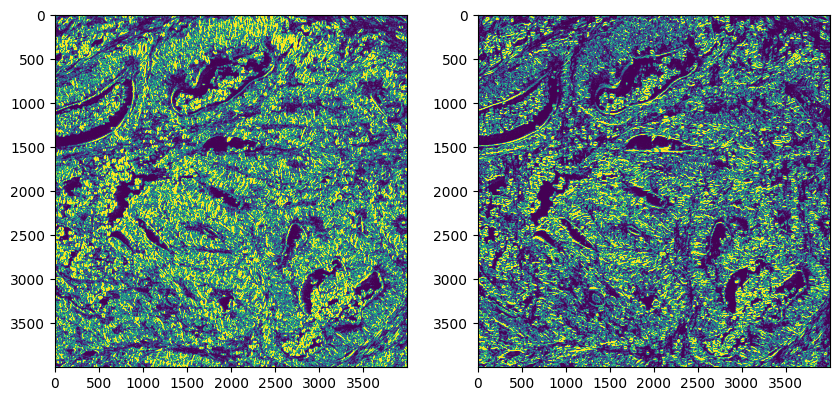

(4000, 4000)
(4000, 4000)


In [8]:
mask_x = sparse_matrix_x_crop_abs != 0
mask_y = sparse_matrix_y_crop_abs != 0
shift, error, diffphase = phase_cross_correlation(sparse_matrix_x_crop, sparse_matrix_y_crop, reference_mask=mask_x, moving_mask=mask_y)
print(shift)
coarse_shift = shift.copy()
sparse_matrix_y_crop_new = sparse_matrix_y[crop_box[0]-int(shift[0]):crop_box[2]-int(shift[0]), crop_box[1]-int(shift[1]):crop_box[3]-int(shift[1])]
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop, vmax=1, vmin=-1)
ax1.imshow(sparse_matrix_y_crop_new, vmax=1, vmin=-1)
plt.show()
sparse_matrix_y_crop_abs = (np.abs(sparse_matrix_y_crop_new).astype(np.uint8)) * 10
sparse_matrix_y_crop_abs = np.where(sparse_matrix_y_crop_abs < 30, 0, sparse_matrix_y_crop_abs)
mask_x = sparse_matrix_x_crop_abs <= 20
mask_y = sparse_matrix_y_crop_abs <= 20
sparse_matrix_x_crop_abs = np.where(sparse_matrix_x_crop_abs < 100, 100, sparse_matrix_x_crop_abs)
sparse_matrix_y_crop_abs = np.where(sparse_matrix_y_crop_abs < 100, 100, sparse_matrix_y_crop_abs)
sparse_matrix_x_crop_abs[mask_x] = 0
sparse_matrix_y_crop_abs[mask_y] = 0
# shift, error, diffphase = phase_cross_correlation(sparse_matrix_x_crop_abs, sparse_matrix_y_crop_abs, reference_mask=mask_x, moving_mask=mask_y, upsample_factor=20)
# print(shift)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop_abs, vmin=0, vmax=62)
ax1.imshow(sparse_matrix_y_crop_abs, vmin=0, vmax=62)
# plt.colorbar()
plt.show()
print(sparse_matrix_x_crop_abs.shape)
print(sparse_matrix_y_crop_abs.shape)

In [9]:
initial_flow = np.full((sparse_matrix_x_crop_abs.shape[0], sparse_matrix_x_crop_abs.shape[1], 2), [0,0], dtype=np.float32)
flow = cv2.calcOpticalFlowFarneback(
    sparse_matrix_x_crop_abs, sparse_matrix_y_crop_abs, initial_flow,
    pyr_scale=0.95, levels=60, winsize=100,
    iterations=32, poly_n=7, poly_sigma=1.5, flags=cv2.OPTFLOW_USE_INITIAL_FLOW
)
# u = flow[:, :, 0] - coarse_shift[1]
# v = flow[:, :, 1] - coarse_shift[0]
u = flow[:, :, 0]
v = flow[:, :, 1]
print(f"u: {u.max()}, {u.min()}")
print(f"v: {v.max()}, {v.min()}")
nr, nc = sparse_matrix_x_crop_abs.shape
row_coords, col_coords = np.meshgrid(np.arange(nr), np.arange(nc), indexing='ij')
sparse_matrix_y_crop_warp = warp(sparse_matrix_y_crop_new, np.array([row_coords + v, col_coords + u]), mode='edge', order=0)
# plt.imsave(os.path.join(result_dir, "test_shift_y_warp.png"), sparse_matrix_y_crop_warp)

u: 24.787796020507812, -0.9938468933105469
v: 5.111660957336426, -17.51446533203125


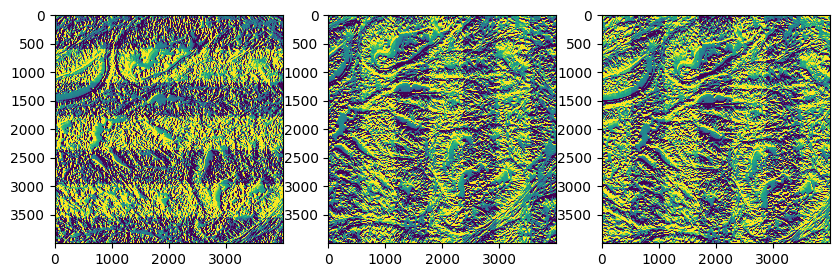

In [10]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop, vmin=-1, vmax=1)
ax1.imshow(sparse_matrix_y_crop, vmin=-1, vmax=1)
ax2.imshow(sparse_matrix_y_crop_warp, vmin=-1, vmax=1)
plt.show()

In [11]:
# 1. 创建画布
fig, ax = plt.subplots()

# 2. 绘制矩阵 (等同于你 imsave 的参数)
im = ax.imshow(sparse_matrix_x_crop, cmap='RdBu', vmin=-15, vmax=15)

# 3. 添加 Colorbar
cbar = fig.colorbar(im)
cbar.solids.set_edgecolor("face") # 关键：防止 SVG 颜色条出现白线

# 4. 移除坐标轴（如果你想让它看起来像 imsave 一样纯净）
# ax.axis('off') 

# 5. 保存为 SVG
save_path = os.path.join(result_dir, "test_shift_x.svg")
plt.savefig(save_path, format='svg', bbox_inches='tight', pad_inches=0.1)
plt.close(fig) # 及时关闭释放内存

In [12]:
plt.imsave(os.path.join(result_dir, "test_shift_x.png"), sparse_matrix_x_crop, cmap='RdBu', vmin=-15, vmax=15)
plt.imsave(os.path.join(result_dir, "test_shift_y_warp.png"), sparse_matrix_y_crop_warp, cmap='RdBu', vmin=-15, vmax=15)

In [13]:
np.save(os.path.join(result_dir, "test_shift_y_warp.npy"), sparse_matrix_y_crop_warp / sparse_matrix_y_crop_warp.max())
np.save(os.path.join(result_dir, "test_shift_x.npy"), sparse_matrix_x_crop / sparse_matrix_x_crop.max())

In [14]:
norm_u_v = np.sqrt(u**2 + v**2)
plt.imsave(os.path.join(result_dir, "test_shift_norm_u_v.png"), norm_u_v)